### Notebook to Paper: Security Assessment of Photonic Integrated Circuit-Based Physically Unclonable Functions

This jupyter notebook generates the plots shown in the paper.
- Some computations are computationally expensive, the corresponding results are stored in res/ as .npz.
Depending on the flags these results are either loaded (to save time) or can be computed again.
- The code works fine for the parameters detailed in the paper. Slight modification of the parameters should be fine as well. Larger parameter changes might require adapting other parameters, recomputing some of the precomputed resources, ...
- The code is rather slow. This is fine as the goal is to demonstrate the idea and not to provide a useful library/framework.

In [1]:
# import the the used libraries and files
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from constants import c0
import lti_puf
import pulse
import boilerplate
import lti_puf_clone
import ffnn_clone

In [2]:
# set the parameters for the simulations
# =========================================================================================================
# disclaimer: if you change some parameters you might need to adapt other ones as well
# (e.g. the intervall given by @start_wavelength and @stop_wavelength must include @carrier_wavelength)
# we did not test the code for a wide set of parameters
# if you want to modify the parameters, expect to might have to dig deep into the code.

# seed the randomness for reproducible results
np.random.seed(89)

# =========================================================================================================
# Parameters of Frequency Response of Moire Grating
# =========================================================================================================
# we use many default parameters, see @transfer_function.py

# wavelength window of moire grating (choose sufficiently large to accomodate sampling bandwidth 1/T_sample)
start_wavelength=1.526e-6 # m
stop_wavelength=1.537e-6 # m

# effective indices in grating, obtained from lumerical simulation
f0, neff0 = boilerplate.load_neff("res/neff_500nm.txt")
f1, neff1 = boilerplate.load_neff("res/neff_480nm.txt")
f2, neff2 = boilerplate.load_neff("res/neff_520nm.txt")

grating_length = 1e-2 # m
manufacturing_variations_segment_length = 2.5e-9 # m

tf_save_path = "res/moire_grating_seed_89/"
load = True # simulation of the frequency responses for all 100 PUFs took approximately 5 hours
# =========================================================================================================

# =========================================================================================================
# Parameters of Challenge Generation and Response Measurement
# =========================================================================================================
samples_per_symbol = 64 # parameter for simulation
modulation_rate = 10e9 # Hz
carrier_wavelength = 1.5305e-6 # m
noise_filter = np.ones(samples_per_symbol) / samples_per_symbol # sets noise bandwidth of receiver

g_t = pulse.Pulse.rectPulse(samples_per_symbol=samples_per_symbol, modulation_rate=modulation_rate)
challenge_length = 32
response_length = 32

# for the fractional hamming distance metric
quant_bits = 3 # number of quantization bits
levels = 2 ** quant_bits
# =========================================================================================================

# =========================================================================================================
# Parameters for training and testing
# =========================================================================================================
# testing
N_puf = 100
N_chal = 100
N_meas = 100
# training
N_train_analytic = 200
N_train_ml = 1000
assert(N_train_ml >= N_train_analytic)

response_pulse_duration = 10 # symbols, duration until p(t) decays approximately to 0
ml_training_epochs = 1000
ml_learning_rate = 1e-5

load_ml = True # load ML responses from npz to avoid long training
# =========================================================================================================

# =========================================================================================================
# Parameters for plotting
# =========================================================================================================
plot_bandwidth = 50e9 # Hz
plot_duration_start = 1 # symbols
plot_duration_end = 10 # symbols
hist_bin_count = 1000
# =========================================================================================================

In [3]:
# compute the frequency responses of N_puf PUFs
# =========================================================================================================
# this is the computationally most expensive part, it takes approximately 6 hours
# hence compute the transfer functions and store them to files or load them from already existing files
tfs = []
if load:
    tfs = boilerplate.load_all_transfer_functions(tf_save_path)
else:
    # Safe mode (abort if any file exists)
    tfs = boilerplate.generate_and_save_transfer_functions(
        save_path=tf_save_path,
        N_puf=N_puf,
        start_wavelength=start_wavelength,
        stop_wavelength=stop_wavelength,
        f0=f0, neff0=neff0,
        f1=f1, neff1=neff1,
        f2=f2, neff2=neff2,
        grating_length=grating_length,
        manufacturing_variations_segment_length=manufacturing_variations_segment_length
    )

✅ Loaded 100 transfer functions from 'res/moire_grating_seed_89/'


In [4]:
# instanciate the PUF objects with the frequency responses
# =========================================================================================================
pufs = []
for tf in tfs:
    pufs.append(lti_puf.LtiPuf(tf, g_t, challenge_length=challenge_length, response_length=response_length, f_carrier=c0 / carrier_wavelength, noise_filter=noise_filter))

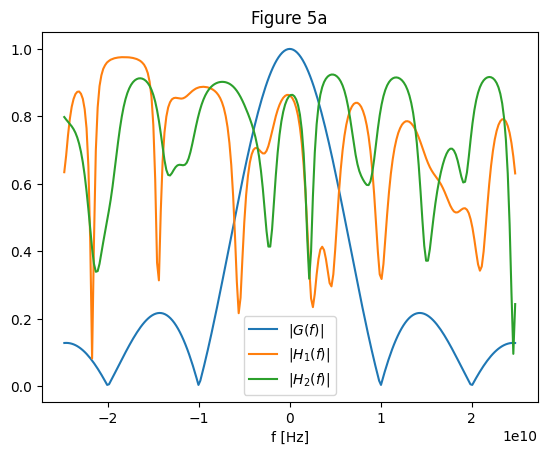

In [5]:
# create Figure 5a
# =========================================================================================================
# plotting the frequency response of the first two PUFs alongside the mangitude response of the pulse
indices_puf = np.logical_and(pufs[0].h_f.freqs >= c0 / carrier_wavelength - plot_bandwidth / 2, pufs[0].h_f.freqs <= c0 / carrier_wavelength + plot_bandwidth / 2)
freq_plot_points = np.sum(indices_puf)
puf_frequencies = pufs[0].h_f.freqs[indices_puf] - c0 / carrier_wavelength
puf1_magnitude_response = np.abs(pufs[0].h_f.h_f[indices_puf])
puf2_magnitude_response = np.abs(pufs[1].h_f.h_f[indices_puf])
puf1_phase_response = np.angle(pufs[0].h_f.h_f[indices_puf])
puf2_phase_response = np.angle(pufs[1].h_f.h_f[indices_puf])

pulse_magnitude_response = np.fft.fftshift(np.abs(np.fft.fft(g_t.g_t, round(freq_plot_points / (g_t.t_sample * plot_bandwidth)))))
pulse_frequencies = np.fft.fftshift(np.fft.fftfreq(len(pulse_magnitude_response), g_t.t_sample))
indices_pulse = np.logical_and(pulse_frequencies >= -plot_bandwidth / 2, pulse_frequencies <= plot_bandwidth / 2)
pulse_frequencies = pulse_frequencies[indices_pulse]
pulse_magnitude_response = pulse_magnitude_response[indices_pulse] / np.max(pulse_magnitude_response[indices_pulse])

plt.title("Figure 5a")
plt.plot(pulse_frequencies, pulse_magnitude_response, label="$|G(f)|$")
plt.plot(puf_frequencies, puf1_magnitude_response, label="$|H_1(f)|$")
plt.plot(puf_frequencies, puf2_magnitude_response, label="$|H_2(f)|$")
# plt.plot(puf_frequencies, puf1_phase_response, label="$arg(H_0(f))$")
# plt.plot(puf_frequencies, puf2_phase_response, label="$arg(H_1(f))$")
plt.xlabel("f [Hz]")
plt.legend()
plt.show()

In [6]:
np.savetxt("export/figure4_G_f.csv",
           np.column_stack((pulse_frequencies, pulse_magnitude_response)),
           delimiter=",", header="f,mag", comments="")

np.savetxt("export/figure4_H1_f.csv",
           np.column_stack((puf_frequencies, puf1_magnitude_response)),
           delimiter=",", header="f,mag", comments="")

np.savetxt("export/figure4_H2_f.csv",
           np.column_stack((puf_frequencies, puf2_magnitude_response)),
           delimiter=",", header="f,mag", comments="")

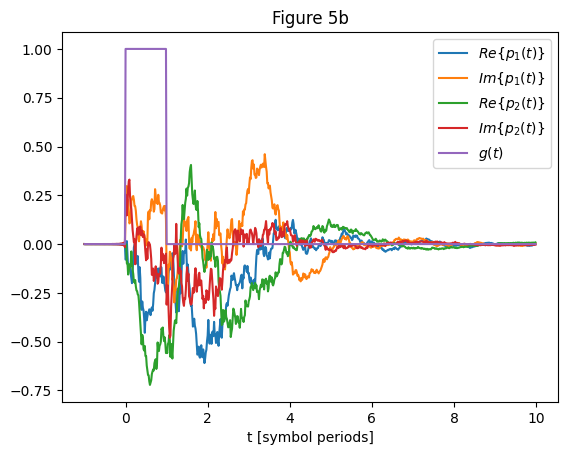

In [7]:
# create Figure 5b
# =========================================================================================================
# plotting the time response of the first two PUFs p_1(t), p_2(t) to the used pulse g(t) alongside the pulse g(t)
plot_samples = samples_per_symbol * (plot_duration_start + plot_duration_end)
t_plot = np.arange(-plot_duration_start, plot_duration_end, 1/samples_per_symbol)
p_t0 = np.roll(pufs[0].getOutputPulse().g_t, plot_duration_start * samples_per_symbol)
p_t1 = np.roll(pufs[1].getOutputPulse().g_t, plot_duration_start * samples_per_symbol)

plt.title("Figure 5b")
plt.plot(t_plot, np.real(p_t0)[:plot_samples], label="$Re\{p_1(t)\}$")
plt.plot(t_plot, np.imag(p_t0)[:plot_samples], label="$Im\{p_1(t)\}$")
plt.plot(t_plot, np.real(p_t1)[:plot_samples], label="$Re\{p_2(t)\}$")
plt.plot(t_plot, np.imag(p_t1)[:plot_samples], label="$Im\{p_2(t)\}$")
g_t_plot = np.roll(np.concatenate((g_t.g_t, np.zeros(len(p_t0) - len(g_t.g_t)))), plot_duration_start * samples_per_symbol)[:plot_samples]
plt.plot(t_plot, g_t_plot, label="$g(t)$")
plt.xlabel("t [symbol periods]")
plt.legend()
plt.show()

In [8]:
# Prepare columns
data = np.column_stack([
    t_plot,
    np.real(p_t0)[:plot_samples],
    np.imag(p_t0)[:plot_samples],
    np.real(p_t1)[:plot_samples],
    np.imag(p_t1)[:plot_samples],
    g_t_plot
])

# Write CSV with header
header = [
    "t",
    "Re_p1",
    "Im_p1",
    "Re_p2",
    "Im_p2",
    "g_t"
]

np.savetxt(
    "export/figure5_data.csv",
    data,
    delimiter=",",
    header=",".join(header),
    comments=""
)

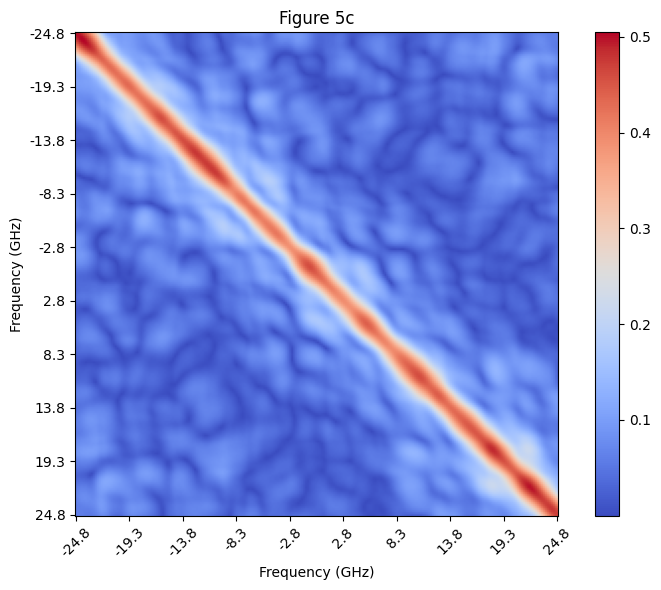

average FWHM: 4.16 GHz


In [9]:
# create Figure 5c
# =========================================================================================================
# plotting the covariance matrix for frequency response
tf_matrix = np.empty((freq_plot_points, len(tfs)), dtype=np.complex128) # rows index the random variables, columns index the samples
for idx in range(len(pufs)):
    tf_matrix[:,idx] = pufs[idx].h_f.h_f[indices_puf]

corr_matrix = np.cov(tf_matrix) #np.corrcoef(tf_matrix)

plt.figure(figsize=(8, 6))
im = plt.imshow(np.abs(corr_matrix), cmap='coolwarm')
plt.colorbar(im)

num_ticks = 10
tick_positions = np.linspace(0, freq_plot_points - 1, num_ticks, dtype=int)
tick_labels = [f"{round(puf_frequencies[i] / 1e9,1):.1f}" for i in tick_positions]

plt.xticks(ticks=tick_positions, labels=tick_labels, rotation=45)
plt.yticks(ticks=tick_positions, labels=tick_labels)

plt.title("Figure 5c")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Frequency (GHz)")
plt.tight_layout()
plt.show()

# compute average FWHM
m = np.abs(corr_matrix)
fwhms = []
for idx, row in enumerate(m[1:-1], start=1):
    left_decorr = np.nonzero(row[:idx] < row[idx] / 2)[0]
    if len(left_decorr) > 0: # ignore rows where left side of maxima is cropped
        right_decorr = np.nonzero(row[idx+1:] < row[idx] / 2)[0]
        if len(right_decorr) > 0: # ignore rows where right side of maxima is cropped
            lwhm = idx - left_decorr[-1]
            rwhm = right_decorr[0]
            fwhms.append(lwhm + rwhm)
print(f"average FWHM: {round(np.average(fwhms) * (puf_frequencies[1] - puf_frequencies[0]) / 1e9, 2)} GHz")

In [10]:
df = pd.DataFrame(np.abs(corr_matrix[::4,::4]), index=puf_frequencies[::4] / 1e9, columns=puf_frequencies[::4] / 1e9) # downsample for faster plotting with pgfplots
df_long = df.stack().reset_index()
df_long.columns = ["x", "y", "value"]
print(len(puf_frequencies) // 4)

df_long.to_csv("export/figure6_data.csv", index=False)

61


In [11]:
# generate test data
# =========================================================================================================
# this takes approximately 7 minutes
challenges = np.random.randint(0, 2, size=(N_chal, challenge_length))
responses = np.empty((N_puf, N_chal, N_meas, response_length), dtype=np.float64)

for p in range(N_puf):
    print(f"evaluating PUF {p} of {N_puf}")
    for c in range(N_chal):
        challenge_symbols = challenges[c] * 2 - 1 # BPSK
        for m in range(N_meas):
            responses[p,c,m,:] = pufs[p].evaluate(challenge_symbols)

evaluating PUF 0 of 100
evaluating PUF 1 of 100
evaluating PUF 2 of 100
evaluating PUF 3 of 100
evaluating PUF 4 of 100
evaluating PUF 5 of 100
evaluating PUF 6 of 100
evaluating PUF 7 of 100
evaluating PUF 8 of 100
evaluating PUF 9 of 100
evaluating PUF 10 of 100
evaluating PUF 11 of 100
evaluating PUF 12 of 100
evaluating PUF 13 of 100
evaluating PUF 14 of 100
evaluating PUF 15 of 100
evaluating PUF 16 of 100
evaluating PUF 17 of 100
evaluating PUF 18 of 100
evaluating PUF 19 of 100
evaluating PUF 20 of 100
evaluating PUF 21 of 100
evaluating PUF 22 of 100
evaluating PUF 23 of 100
evaluating PUF 24 of 100
evaluating PUF 25 of 100
evaluating PUF 26 of 100
evaluating PUF 27 of 100
evaluating PUF 28 of 100
evaluating PUF 29 of 100
evaluating PUF 30 of 100
evaluating PUF 31 of 100
evaluating PUF 32 of 100
evaluating PUF 33 of 100
evaluating PUF 34 of 100
evaluating PUF 35 of 100
evaluating PUF 36 of 100
evaluating PUF 37 of 100
evaluating PUF 38 of 100
evaluating PUF 39 of 100
evaluating

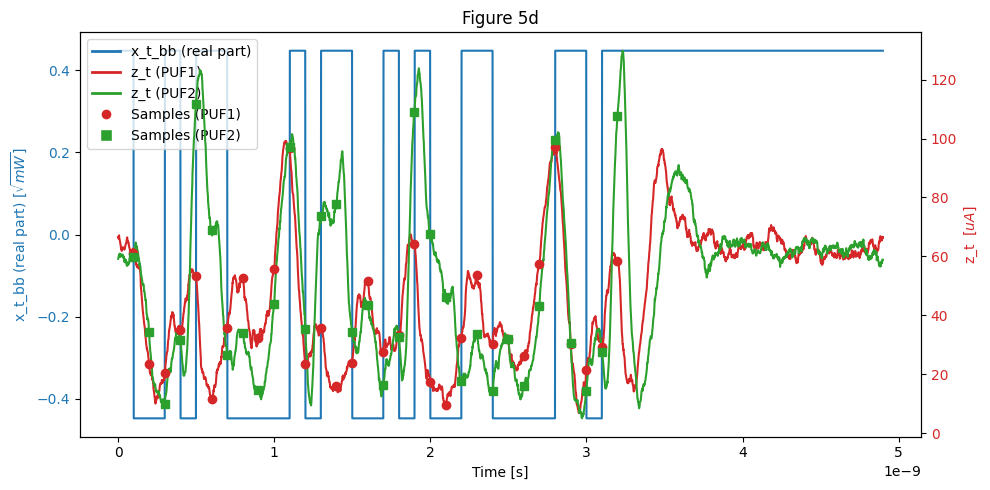

In [12]:
# create Figure 5d
# =========================================================================================================
pufs[0].return_analog = True # set flags for PUF object to return as well the analog values
pufs[1].return_analog = True
response1, z_t_filtered1, x_t_bb1 = pufs[0].evaluate(challenges[0] * 2 - 1)
response2, z_t_filtered2, x_t_bb2 = pufs[1].evaluate(challenges[0] * 2 - 1)

t_x = np.arange(len(x_t_bb1)) * g_t.t_sample
t_z = np.arange(len(z_t_filtered1)) * g_t.t_sample

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_title("Figure 5d")
ax1.plot(t_x, np.real(x_t_bb1) * np.sqrt(  1e3), color='tab:blue', label="x_t_bb (real part)")
ax1.set_xlabel("Time [s]")
ax1.set_ylabel(r"x_t_bb (real part) $[\sqrt{mW}]$", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(t_z, z_t_filtered1 * 1e6, color='tab:red', label="z_t")
ax2.plot(t_z, z_t_filtered2 * 1e6, color='tab:green', label="z_t")
ax2.set_ylabel(r"z_t  $[uA]$", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Add sample markers for both PUFs
sample_indices1 = np.arange(pufs[0].sample_offset, pufs[0].sample_offset + pufs[0].sprs * pufs[0].resp_len, pufs[0].sprs)
sample_indices2 = np.arange(pufs[1].sample_offset, pufs[1].sample_offset + pufs[1].sprs * pufs[1].resp_len, pufs[1].sprs)

ax2.plot(t_z[sample_indices1], z_t_filtered1[sample_indices1] * 1e6, 'o', color='tab:red', markersize=6)
ax2.plot(t_z[sample_indices2], z_t_filtered2[sample_indices2] * 1e6, 's', color='tab:green', markersize=6)

# Add legend entries for the sample markers
custom_lines = [Line2D([0], [0], color='tab:blue', lw=2),
                 Line2D([0], [0], color='tab:red', lw=2),
                 Line2D([0], [0], color='tab:green', lw=2),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red', markersize=8),
                 Line2D([0], [0], marker='s', color='w', markerfacecolor='tab:green', markersize=8)]
ax1.legend(custom_lines, ['x_t_bb (real part)', 'z_t (PUF1)', 'z_t (PUF2)', 'Samples (PUF1)', 'Samples (PUF2)'], loc='upper left')

fig.tight_layout()
plt.show()

pufs[0].return_analog = False # reset flags
pufs[1].return_analog = False

In [13]:
df_main = pd.DataFrame({
    "t_x": t_x,
    "x_t_bb_real": np.real(x_t_bb1)
})
df_main.to_csv("export/figure7_xtbb.csv", index=False)

df_z = pd.DataFrame({
    "t_z": t_z,
    "z_t_puf1": z_t_filtered1,
    "z_t_puf2": z_t_filtered2
})
df_z.to_csv("export/figure7_zt.csv", index=False)

df_samples1 = pd.DataFrame({
    "t_samples_puf1": t_z[sample_indices1],
    "z_samples_puf1": z_t_filtered1[sample_indices1]
})
df_samples1.to_csv("export/figure7_samples_puf1.csv", index=False)

df_samples2 = pd.DataFrame({
    "t_samples_puf2": t_z[sample_indices2],
    "z_samples_puf2": z_t_filtered2[sample_indices2]
})
df_samples2.to_csv("export/figure7_samples_puf2.csv", index=False)

In [14]:
# create the training data
# =========================================================================================================
train_challenges = np.random.randint(0, 2, size=(N_train_ml, challenge_length)).astype(np.float64)
train_symbols = train_challenges * 2 - 1  # BPSK
train_responses = np.empty((N_puf, N_train_ml, response_length), dtype=np.float64)
for p in range(N_puf):
    print(f"evaluating PUF {p} of {N_puf}")
    for c in range(N_train_ml):
        train_responses[p,c,:] = pufs[p].evaluate(train_symbols[c])

evaluating PUF 0 of 100
evaluating PUF 1 of 100
evaluating PUF 2 of 100
evaluating PUF 3 of 100
evaluating PUF 4 of 100
evaluating PUF 5 of 100
evaluating PUF 6 of 100
evaluating PUF 7 of 100
evaluating PUF 8 of 100
evaluating PUF 9 of 100
evaluating PUF 10 of 100
evaluating PUF 11 of 100
evaluating PUF 12 of 100
evaluating PUF 13 of 100
evaluating PUF 14 of 100
evaluating PUF 15 of 100
evaluating PUF 16 of 100
evaluating PUF 17 of 100
evaluating PUF 18 of 100
evaluating PUF 19 of 100
evaluating PUF 20 of 100
evaluating PUF 21 of 100
evaluating PUF 22 of 100
evaluating PUF 23 of 100
evaluating PUF 24 of 100
evaluating PUF 25 of 100
evaluating PUF 26 of 100
evaluating PUF 27 of 100
evaluating PUF 28 of 100
evaluating PUF 29 of 100
evaluating PUF 30 of 100
evaluating PUF 31 of 100
evaluating PUF 32 of 100
evaluating PUF 33 of 100
evaluating PUF 34 of 100
evaluating PUF 35 of 100
evaluating PUF 36 of 100
evaluating PUF 37 of 100
evaluating PUF 38 of 100
evaluating PUF 39 of 100
evaluating

In [15]:
# compute inter and intra distances
# =========================================================================================================

# euclidean distance
d_intra_euclidean = np.empty((N_puf, N_chal, N_meas * (N_meas - 1) // 2), dtype=np.float64)
for m in range(N_meas-1):
    start_idx = m*N_meas - (m+1)*m//2 # (N - 1) + (N - 2) + ... + (N - m)
    end_idx = start_idx + N_meas - 1 - m
    d_intra_euclidean[:,:,start_idx:end_idx] = np.linalg.norm(responses[:,:,m:m+1,:] - responses[:,:,m+1:,:],axis=-1)

d_inter_euclidean = np.empty((N_puf * (N_puf - 1) // 2, N_chal, N_meas), dtype=np.float64)
for p in range(N_puf):
    start_idx = p*N_puf - (p+1)*p//2 # (N - 1) + (N - 2) + ... + (N - p)
    d_inter_euclidean[start_idx:start_idx + N_puf - 1 - p,:,:] = np.linalg.norm(responses[p:p+1,:,:,:] - responses[p+1:,:,:,:], axis=-1)

# fractional hamming distance

# Quantize into integer bins [0, 7] and gray code them, quantization is done such that each bin is equiprobable
quant_edges = np.quantile(responses.flatten(), np.linspace(0, 1, levels + 1))
quant_responses = np.digitize(responses, quant_edges[1:-1]).astype(np.uint8)
gray_responses = quant_responses ^ (quant_responses >> 1)

d_intra_hamming = np.empty((N_puf, N_chal, N_meas * (N_meas - 1) // 2), dtype=np.float64)
for m in range(N_meas-1):
    start_idx = m*N_meas - (m+1)*m//2 # (N - 1) + (N - 2) + ... + (N - m)
    end_idx = start_idx + N_meas - 1 - m
    d_intra_hamming[:,:,start_idx:end_idx] = np.sum(np.unpackbits(np.bitwise_xor(gray_responses[:,:,m:m+1,:], gray_responses[:,:,m+1:,:]),axis=-1), axis=-1) / (challenge_length * quant_bits) # fractional hamming distance 

d_inter_hamming = np.empty((N_puf * (N_puf - 1) // 2, N_chal, N_meas), dtype=np.float64)
for p in range(N_puf):
    start_idx = p*N_puf - (p+1)*p//2 # (N - 1) + (N - 2) + ... + (N - p)
    d_inter_hamming[start_idx:start_idx + N_puf - 1 - p,:,:] = np.sum(np.unpackbits(np.bitwise_xor(gray_responses[p:p+1,:,:,:], gray_responses[p+1:,:,:,:]), axis=-1), axis=-1) / (challenge_length * quant_bits)


learning PUF 0 of 100
learning PUF 1 of 100
learning PUF 2 of 100
learning PUF 3 of 100
learning PUF 4 of 100
learning PUF 5 of 100
learning PUF 6 of 100
learning PUF 7 of 100
learning PUF 8 of 100
learning PUF 9 of 100
learning PUF 10 of 100
learning PUF 11 of 100
learning PUF 12 of 100
learning PUF 13 of 100
learning PUF 14 of 100
learning PUF 15 of 100
learning PUF 16 of 100
learning PUF 17 of 100
learning PUF 18 of 100
learning PUF 19 of 100
learning PUF 20 of 100
learning PUF 21 of 100
learning PUF 22 of 100
learning PUF 23 of 100
learning PUF 24 of 100
learning PUF 25 of 100
learning PUF 26 of 100
learning PUF 27 of 100
learning PUF 28 of 100
learning PUF 29 of 100
learning PUF 30 of 100
learning PUF 31 of 100
learning PUF 32 of 100
learning PUF 33 of 100
learning PUF 34 of 100
learning PUF 35 of 100
learning PUF 36 of 100
learning PUF 37 of 100
learning PUF 38 of 100
learning PUF 39 of 100
learning PUF 40 of 100
learning PUF 41 of 100
learning PUF 42 of 100
learning PUF 43 of 10

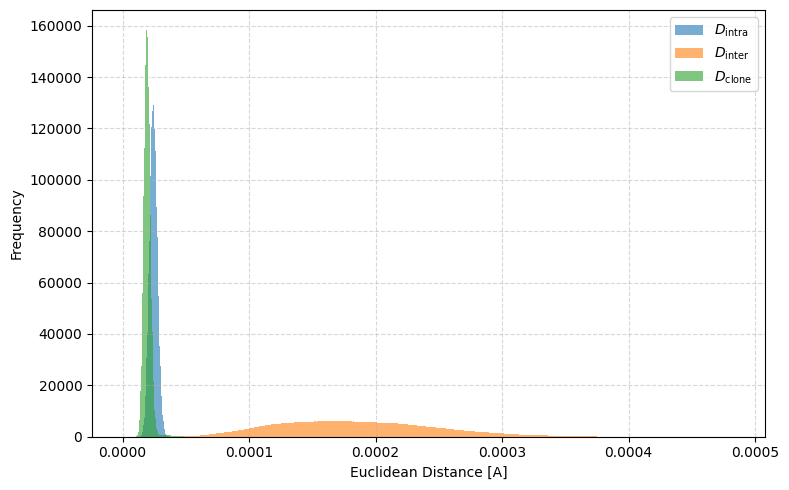

In [16]:
# D_intra, D_inter and D_clone for the analytical model with the euclidean distance

# train analytic clones and create response dataset
analytic_clone_responses = np.empty((N_puf, N_chal, challenge_length), dtype=np.float64)
for p in range(N_puf):
    print(f"learning PUF {p} of {N_puf}")
    clone = lti_puf_clone.LtiPufClone(challenges=train_symbols[:N_train_analytic], responses=train_responses[p][:N_train_analytic], \
                        response_pulse_duration = response_pulse_duration, sample_offset = pufs[0].sample_offset, \
                        samples_per_challenge_symbol = pufs[0].g_t.sps, samples_per_response_symbol = pufs[0].sprs)
    for c in range(N_chal):
        challenge_symbols = challenges[c] * 2 - 1 # BPSK
        analytic_clone_responses[p,c,:] = clone.evaluate(challenge_symbols)

# eculidean distance
d_analytic_clone_euclidean = np.linalg.norm(responses - analytic_clone_responses[:,:,np.newaxis,:], axis=-1)

d_intra_eucl_flat = d_intra_euclidean.flatten()
d_inter_eucl_flat = d_inter_euclidean.flatten()
d_anal_clone_eucl_flat = d_analytic_clone_euclidean.flatten()

# Plot histograms
euclidean_bins = np.linspace(0, np.max(d_inter_eucl_flat), hist_bin_count)


plt.figure(figsize=(8,5))
plt.hist(d_intra_eucl_flat, bins=euclidean_bins, alpha=0.6, label='$D_\mathrm{intra}$', density=True)
plt.hist(d_inter_eucl_flat, bins=euclidean_bins, alpha=0.6, label='$D_\mathrm{inter}$', density=True)
plt.hist(d_anal_clone_eucl_flat, bins=euclidean_bins, alpha=0.6, label='$D_\mathrm{clone}$', density=True)

plt.xlabel('Euclidean Distance [A]')
plt.ylabel('Frequency')
# plt.yscale('log')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


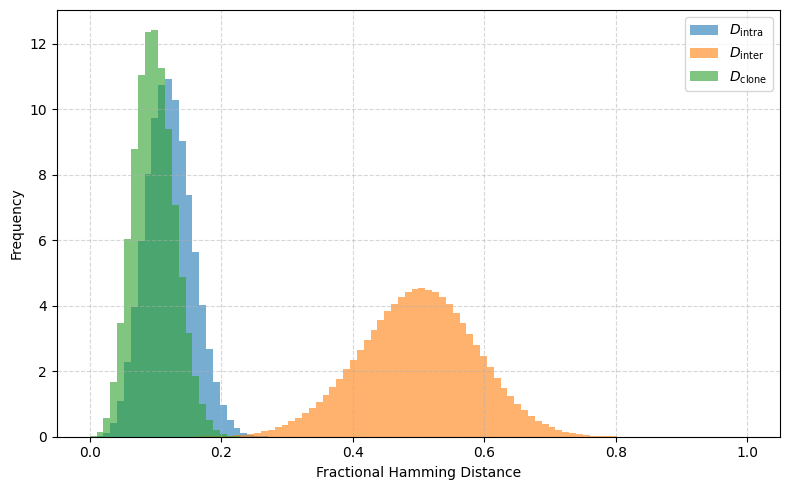

mean D_intra: 0.1161442112794613, var D_intra: 0.0012799438727547437
mean D_inter: 0.4936026292087542, var D_inter: 0.007803342323306116
mean D_clone: 0.09317147916666665, var D_clone: 0.0009823400098259549



In [17]:
# D_intra, D_inter and D_clone for the analytical model with the fractional hamming distance
quant_anal_responses = np.digitize(analytic_clone_responses, quant_edges[1:-1]).astype(np.uint8)
gray_anal_responses = quant_anal_responses ^ (quant_anal_responses >> 1)
d_analytic_clone_hamming = np.sum(np.unpackbits(np.bitwise_xor(gray_responses, gray_anal_responses[:,:,np.newaxis,:]),axis=-1), axis=-1) / (challenge_length * quant_bits)

d_intra_q_flat = d_intra_hamming.flatten()
d_inter_q_flat = d_inter_hamming.flatten()
d_clone_q_flat = d_analytic_clone_hamming.flatten()

# Plot histograms
hamming_bins = np.linspace(0, 1, challenge_length * quant_bits + 1)

plt.figure(figsize=(8,5))
plt.hist(d_intra_q_flat, bins=hamming_bins, alpha=0.6, label='$D_\mathrm{intra}$', density=True)
plt.hist(d_inter_q_flat, bins=hamming_bins, alpha=0.6, label='$D_\mathrm{inter}$', density=True)
plt.hist(d_clone_q_flat, bins=hamming_bins, alpha=0.6, label='$D_\mathrm{clone}$', density=True)

plt.xlabel('Fractional Hamming Distance')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"mean D_intra: {np.mean(d_intra_q_flat)}, var D_intra: {np.var(d_intra_q_flat)}\n" \
      f"mean D_inter: {np.mean(d_inter_q_flat)}, var D_inter: {np.var(d_inter_q_flat)}\n" \
      f"mean D_clone: {np.mean(d_clone_q_flat)}, var D_clone: {np.var(d_clone_q_flat)}\n")

training with learning rate 1e-05 and 1000 samples


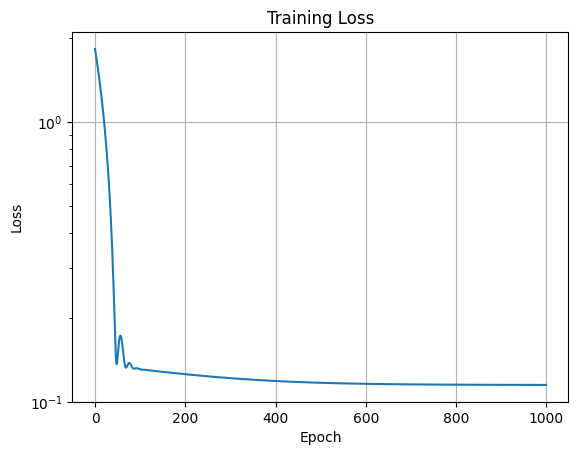

mean test error: 2.243130440938131
training with learning rate 1.0000000000000002e-06 and 1000 samples


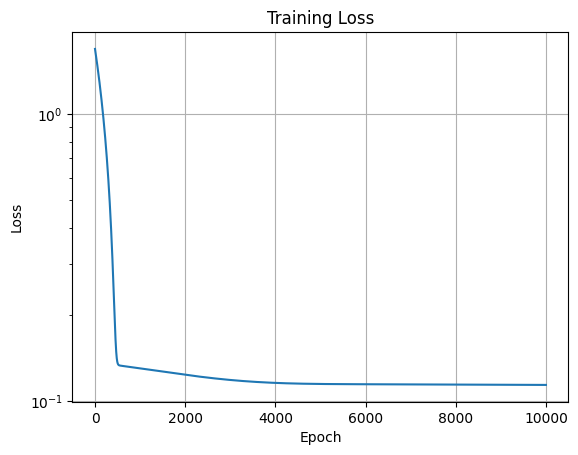

training with learning rate 1e-05 and 10000 samples


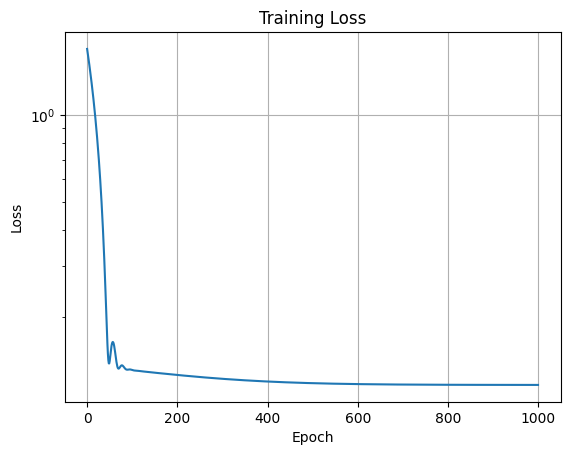

In [18]:
# investigate choice of ML hyperparameters
# =========================================================================================================
# demonstrate that choice of iteration leads to convergence
print(f"training with learning rate {ml_learning_rate} and {len(train_symbols)} samples")
model_puf = ffnn_clone.FFNNClone(train_symbols, train_responses[0] * 1e3, hidden_layers=[challenge_length**2]*2, learning_rate=ml_learning_rate, epochs=ml_training_epochs, batch_size=N_train_ml, plot=True)

# absence of overfitting can be verified by comparing training and test loss
print(f"mean test error: {np.mean(np.linalg.norm(responses[0,:,0,:] - model_puf.evaluate(challenges * 2 - 1)))}")

# demonstrate that decreasing learning rate does not yield significant improvement in final training loss
print(f"training with learning rate {ml_learning_rate / 10} and {len(train_symbols)} samples")
ffnn_clone.FFNNClone(train_symbols, train_responses[0]  * 1e3, hidden_layers=[challenge_length**2]*2, learning_rate=ml_learning_rate / 10, epochs=ml_training_epochs * 10, batch_size=N_train_ml, plot=True)

# demonstrate that increasing training set size only leads to small improvement
print(f"training with learning rate {ml_learning_rate} and {len(train_symbols) * 10} samples")
more_train_challenges = np.random.randint(0, 2, size=(10 * N_train_ml, challenge_length)).astype(np.float32)
more_train_symbols = more_train_challenges * 2 - 1  # BPSK mapping to ±1
more_train_responses = np.array([pufs[0].evaluate(s) for s in more_train_symbols])
ffnn_clone.FFNNClone(more_train_symbols, more_train_responses  * 1e3, hidden_layers=[challenge_length**2]*2, learning_rate=ml_learning_rate, epochs=ml_training_epochs, batch_size=N_train_ml * 10, plot=True)

In [19]:
# D_intra, D_inter and D_clone for the ML model with the euclidean distance
# training the ML models is computationally expensive (due to the sigmoid activation function) and takes approximately 1 hour and 15 minutes

# train ML clones and create response dataset
if not load_ml:
    ml_clone_responses = np.empty((N_puf, N_chal, challenge_length), dtype=np.float64)
    for p in range(N_puf):
        print(f"learning PUF {p} of {N_puf}")
        clone = ffnn_clone.FFNNClone(train_symbols, train_responses[p] * 1e3, hidden_layers=[challenge_length**2]*2, learning_rate=ml_learning_rate, epochs=ml_training_epochs, batch_size=N_train_ml, plot=False)
        for c in range(N_chal):
            challenge_symbols = challenges[c] * 2 - 1 # BPSK
            ml_clone_responses[p,c,:] = clone.evaluate(challenge_symbols) / 1e3 # training on small output values yields worse performance, so we train on larger output values and scale back to the smaller values

    save_dict = {
        'ml_clone_responses': ml_clone_responses
    }
    np.savez('res/ml_clone_responses_seed_89.npz', **save_dict)
else:
    data = np.load('res/ml_clone_responses_seed_89.npz')
    ml_clone_responses = data['ml_clone_responses']

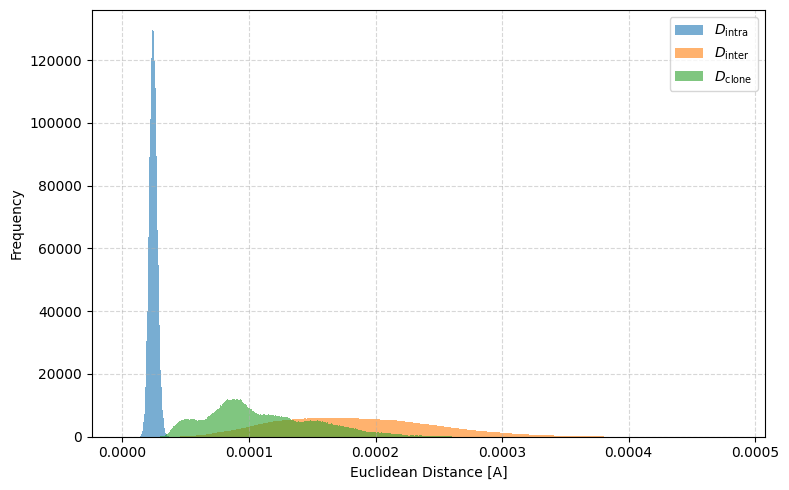

In [20]:
# eculidean distance
d_ml_clone_euclidean = np.linalg.norm(responses - ml_clone_responses[:,:,np.newaxis,:], axis=-1)
d_ml_clone_eucl_flat = d_ml_clone_euclidean.flatten()

plt.figure(figsize=(8,5))
plt.hist(d_intra_eucl_flat, bins=euclidean_bins, alpha=0.6, label='$D_\mathrm{intra}$', density=True)
plt.hist(d_inter_eucl_flat, bins=euclidean_bins, alpha=0.6, label='$D_\mathrm{inter}$', density=True)
plt.hist(d_ml_clone_eucl_flat, bins=euclidean_bins, alpha=0.6, label='$D_\mathrm{clone}$', density=True)

plt.xlabel('Euclidean Distance [A]')
plt.ylabel('Frequency')
# plt.yscale('log')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

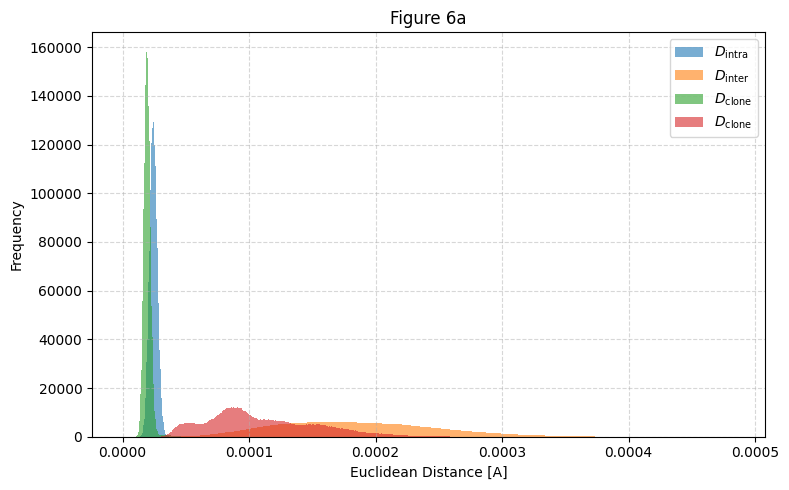

In [21]:
# create Figure 6a
# =========================================================================================================

plt.figure(figsize=(8,5))
plt.title('Figure 6a')
plt.hist(d_intra_eucl_flat, bins=euclidean_bins, alpha=0.6, label='$D_\mathrm{intra}$', density=True)
plt.hist(d_inter_eucl_flat, bins=euclidean_bins, alpha=0.6, label='$D_\mathrm{inter}$', density=True)
plt.hist(d_anal_clone_eucl_flat, bins=euclidean_bins, alpha=0.6, label='$D_\mathrm{clone}$', density=True)
plt.hist(d_ml_clone_eucl_flat, bins=euclidean_bins, alpha=0.6, label='$D_\mathrm{clone}$', density=True)
plt.xlabel('Euclidean Distance [A]')
plt.ylabel('Frequency')
# plt.yscale('log')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [22]:
# Compute histogram densities
hist_intra, bins = np.histogram(d_intra_eucl_flat, bins=euclidean_bins, density=True)
hist_inter, _    = np.histogram(d_inter_eucl_flat, bins=euclidean_bins, density=True)
hist_clone, _    = np.histogram(d_anal_clone_eucl_flat, bins=euclidean_bins, density=True)
hist_clone_ml, _    = np.histogram(d_ml_clone_eucl_flat, bins=euclidean_bins, density=True)

# Build dataframe for pgfplots
df = pd.DataFrame({
    "bin_left": bins[:-1],
    "bin_right": bins[1:],
    "D_intra": hist_intra,
    "D_inter": hist_inter,
    "D_clone_anal": hist_clone,
    "D_clone_ml": hist_clone_ml
})

df.to_csv("export/figure16_histograms.csv", index=False)

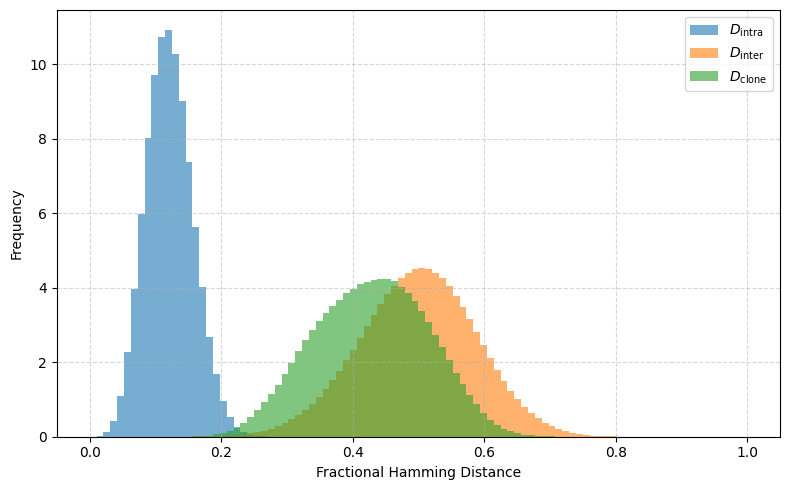

In [23]:
# D_intra, D_inter and D_clone for the ML model with the fractional hamming distance
quant_ml_responses = np.digitize(ml_clone_responses, quant_edges[1:-1]).astype(np.uint8)
gray_ml_responses = quant_ml_responses ^ (quant_ml_responses >> 1)
d_ml_clone_hamming = np.sum(np.unpackbits(np.bitwise_xor(gray_responses, gray_ml_responses[:,:,np.newaxis,:]),axis=-1), axis=-1) / (challenge_length * quant_bits)


d_ml_clone_q_flat = d_ml_clone_hamming.flatten()

plt.figure(figsize=(8,5))
plt.hist(d_intra_q_flat, bins=hamming_bins, alpha=0.6, label='$D_\mathrm{intra}$', density=True)
plt.hist(d_inter_q_flat, bins=hamming_bins, alpha=0.6, label='$D_\mathrm{inter}$', density=True)
plt.hist(d_ml_clone_q_flat, bins=hamming_bins, alpha=0.6, label='$D_\mathrm{clone}$', density=True)

plt.xlabel('Fractional Hamming Distance')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

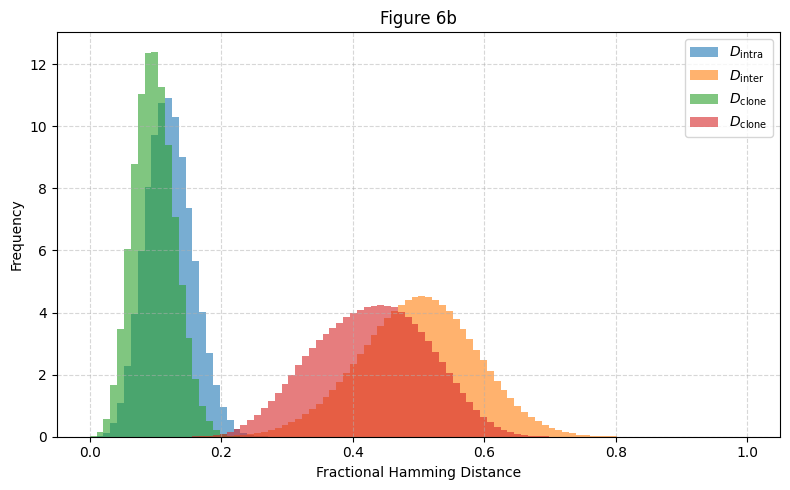

In [24]:
# create Figure 6b
# =========================================================================================================
# D_intra, D_inter and D_clone for both analytical and ML models with fractional hamming distance

plt.figure(figsize=(8,5))

plt.hist(d_intra_q_flat, bins=hamming_bins, alpha=0.6, label='$D_\mathrm{intra}$', density=True)
plt.hist(d_inter_q_flat, bins=hamming_bins, alpha=0.6, label='$D_\mathrm{inter}$', density=True)
plt.hist(d_clone_q_flat, bins=hamming_bins, alpha=0.6, label='$D_\mathrm{clone}$', density=True)
plt.hist(d_ml_clone_q_flat, bins=hamming_bins, alpha=0.6, label='$D_\mathrm{clone}$', density=True)
plt.title('Figure 6b')
plt.xlabel('Fractional Hamming Distance')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [25]:
# Build dataframe for pgfplots

# Compute histogram densities
hist_intra_q, bins_q = np.histogram(d_intra_q_flat, bins=hamming_bins, density=False)
hist_inter_q, _    = np.histogram(d_inter_q_flat, bins=hamming_bins, density=False)
hist_clone_q, _    = np.histogram(d_clone_q_flat, bins=hamming_bins, density=False)
hist_ml_clone_q, _    = np.histogram(d_ml_clone_q_flat, bins=hamming_bins, density=False)

df = pd.DataFrame({
    "bin_left": bins_q[:-1],
    "bin_right": bins_q[1:],
    "D_intra": hist_intra_q / len(d_intra_q_flat), # we normalize such that it is a probability mass function (discrete set of bins so not a density)
    "D_inter": hist_inter_q / len(d_inter_q_flat),
    "D_clone_anal": hist_clone_q / len(d_clone_q_flat),
    "D_clone_ml": hist_ml_clone_q / len(d_ml_clone_q_flat)
})

df.to_csv("export/figure17_histograms.csv", index=False)

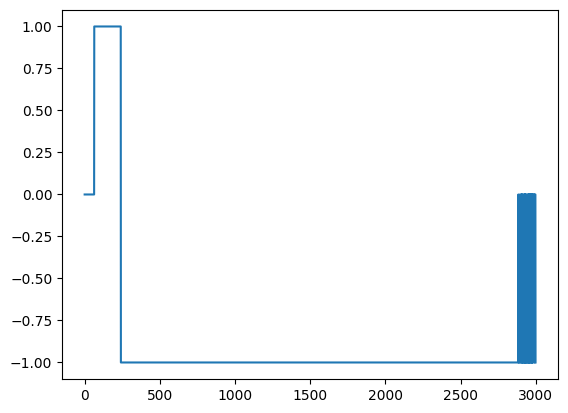

edges: [  63  240 2883 2884 2893 2894 2900 2904 2906 2907 2910 2912 2917 2918
 2924 2925 2926 2927 2929 2930 2931 2932 2937 2938 2945 2946 2949 2951
 2953 2955 2956 2958 2961 2963 2966 2969 2970 2973 2975 2976 2978 2981
 2982 2990 2992 2997]
threshold: 3.869128849984243e-05
intra: 9.523716132801733 -> 7.393411208359551
inter: 7.1427870996013 -> 8.270595589012379
FAR: 1.5494949494949497e-05, FRR: 6.262626262626263e-06
Analytic FAR: 0.998079, ML FAR: 0.007562


In [26]:
# compute the values for Table 2
# =========================================================================================================
# compute FRR and FAR for the various scenarios to create a table to compare analytic and ML based attack
# objective function: FAR(thresh) + FRR(tresh) -> minimal at intersection of densities
# 1. compute intersection of D_intra and D_inter densities -> threshould
# 2. compute FRR and FAR for threshold
# 3. compute FAR for analytic clone
# 4. compute FAR for ML clone

# 2 options
# 1. if enough samples we can compute these values directly on the histogramms
# 2. if not enough samples, we fit a gaussian distribution and compute the values based on the fitted distribution

euclidean_bins = np.linspace(0, np.max(d_inter_eucl_flat), int(3e3)) # 3000 bins is the finest resolution, before the edge becomes blurry
hist_intra, bins = np.histogram(d_intra_eucl_flat, bins=euclidean_bins, density=True)
hist_inter, _    = np.histogram(d_inter_eucl_flat, bins=euclidean_bins, density=True)
hist_clone, _    = np.histogram(d_anal_clone_eucl_flat, bins=euclidean_bins, density=True)
hist_clone_ml, _    = np.histogram(d_ml_clone_eucl_flat, bins=euclidean_bins, density=True)

plt.plot(np.sign(hist_intra - hist_inter))
plt.show()
# -> option 1. is fine

edges = np.nonzero(np.diff(np.sign(hist_intra - hist_inter)))[0]
print(f"edges: {edges}")
edge = edges[1]
print(f"threshold: {bins[edge]}")
print(f"intra: {hist_intra[edge]} -> {hist_intra[edge+1]}")
print(f"inter: {hist_inter[edge]} -> {hist_inter[edge+1]}")

intra_pmf = hist_intra * np.diff(bins)
inter_pmf = hist_inter * np.diff(bins)
FRR = np.sum(intra_pmf[edge+1:])
FAR = np.sum(inter_pmf[:edge+1])
print(f"FAR: {FAR}, FRR: {FRR}")

clone_analytic_pmf = hist_clone * np.diff(bins)
FAR_analytic_clone = np.sum(clone_analytic_pmf[:edge+1])

clone_ml_pmf = hist_clone_ml * np.diff(bins)
FAR_ml_clone = np.sum(clone_ml_pmf[:edge+1])
print(f"Analytic FAR: {FAR_analytic_clone}, ML FAR: {FAR_ml_clone}")

### Extras as outlook, not included in paper

learning PUF 0 of 100
learning PUF 1 of 100
learning PUF 2 of 100
learning PUF 3 of 100
learning PUF 4 of 100
learning PUF 5 of 100
learning PUF 6 of 100
learning PUF 7 of 100
learning PUF 8 of 100
learning PUF 9 of 100
learning PUF 10 of 100
learning PUF 11 of 100
learning PUF 12 of 100
learning PUF 13 of 100
learning PUF 14 of 100
learning PUF 15 of 100
learning PUF 16 of 100
learning PUF 17 of 100
learning PUF 18 of 100
learning PUF 19 of 100
learning PUF 20 of 100
learning PUF 21 of 100
learning PUF 22 of 100
learning PUF 23 of 100
learning PUF 24 of 100
learning PUF 25 of 100
learning PUF 26 of 100
learning PUF 27 of 100
learning PUF 28 of 100
learning PUF 29 of 100
learning PUF 30 of 100
learning PUF 31 of 100
learning PUF 32 of 100
learning PUF 33 of 100
learning PUF 34 of 100
learning PUF 35 of 100
learning PUF 36 of 100
learning PUF 37 of 100
learning PUF 38 of 100
learning PUF 39 of 100
learning PUF 40 of 100
learning PUF 41 of 100
learning PUF 42 of 100
learning PUF 43 of 10

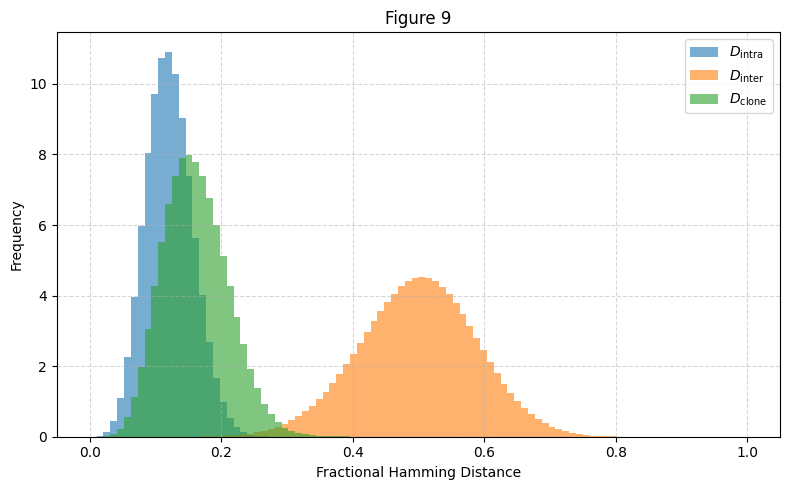

In [27]:
# create Figure *
# =========================================================================================================
# test training our analytic model on quantized responses
# use as value bin center value

quant_center = (quant_edges[:-1] + quant_edges[1:]) / 2

# train analytic clones and create response dataset
analog_quant_analytic_clone_responses = np.empty((N_puf, N_chal, challenge_length), dtype=np.float64)
for p in range(N_puf):
    print(f"learning PUF {p} of {N_puf}")
    train_quant_responses = quant_center[np.digitize(train_responses[p], quant_edges[1:-1]).astype(np.uint8)]
    clone = lti_puf_clone.LtiPufClone(challenges=train_symbols[:N_train_analytic], responses=train_quant_responses[:N_train_analytic], \
                        response_pulse_duration = response_pulse_duration, sample_offset = pufs[0].sample_offset, \
                        samples_per_challenge_symbol = pufs[0].g_t.sps, samples_per_response_symbol = pufs[0].sprs)
    for c in range(N_chal):
        challenge_symbols = challenges[c] * 2 - 1 # BPSK
        analog_quant_analytic_clone_responses[p,c,:] = clone.evaluate(challenge_symbols)

analog_quant_quant_anal_responses = np.digitize(analog_quant_analytic_clone_responses, quant_edges[1:-1]).astype(np.uint8)
analog_quant_gray_anal_responses = analog_quant_quant_anal_responses ^ (analog_quant_quant_anal_responses >> 1)
analog_quant_d_analytic_clone_hamming = np.sum(np.unpackbits(np.bitwise_xor(gray_responses, analog_quant_gray_anal_responses[:,:,np.newaxis,:]),axis=-1), axis=-1) / (challenge_length * quant_bits)

analog_quant_d_clone_q_flat = analog_quant_d_analytic_clone_hamming.flatten()

# Plot histograms
hamming_bins = np.linspace(0, 1, challenge_length * quant_bits + 1)

plt.figure(figsize=(8,5))
plt.hist(d_intra_q_flat, bins=hamming_bins, alpha=0.6, label='$D_\mathrm{intra}$', density=True)
plt.hist(d_inter_q_flat, bins=hamming_bins, alpha=0.6, label='$D_\mathrm{inter}$', density=True)
plt.hist(analog_quant_d_clone_q_flat, bins=hamming_bins, alpha=0.6, label='$D_\mathrm{clone}$', density=True)

plt.title('Figure 9')
plt.xlabel('Fractional Hamming Distance')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()